In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import xgboost as xgb

In [ ]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [ ]:
train.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

In [ ]:
train.describe()

,id,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000
mean,297096.500000,0.114102,36.577258,65.866223,2494.377057
std,171529.177262,0.317936,25.061922,31.067444,2353.916710
min,0.000000,0.000000,1.000000,18.250000,18.800000
25%,148548.250000,0.000000,12.000000,29.900000,639.650000
50%,297096.500000,0.000000,35.000000,74.100000,1433.650000
75%,445644.750000,0.000000,62.000000,90.800000,4263.800000
max,594193.000000,1.000000,72.000000,118.750000,8684.800000


In [ ]:
test['Churn'] = np.nan
data = pd.concat([train, test], axis=0).reset_index(drop=True)

In [ ]:
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    if data[col].dtype == object:
        data[col] = (data[col] == 'Yes').astype(int)
    if col == 'gender' and data[col].dtype == object:
        data[col] = (data[col] == 'Male').astype(int)

In [ ]:
contract_map = {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
data['Contract'] = data['Contract'].map(contract_map)

In [ ]:
service_cols = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
service_map = {'No internet service': 0, 'No phone service': 0, 'No': 1, 'Yes': 2}
for col in service_cols:
    data[col] = data[col].map(service_map)

In [ ]:
data = pd.get_dummies(data, columns=['InternetService', 'PaymentMethod'], dtype=int)

In [ ]:
data['AvgMonthlySpend']   = data['TotalCharges'] / (data['tenure'] + 1)
data['ChargeConsistency'] = data['TotalCharges'] / (data['MonthlyCharges'] * (data['tenure'] + 1) + 1)
data['TenureGroup']       = pd.cut(data['tenure'], bins=[-1, 12, 24, 48, 72], labels=[0,1,2,3]).astype(int)
data['ServiceCount']      = data[service_cols].apply(lambda row: (row == 2).sum(), axis=1)
data['ChargePerService']  = data['MonthlyCharges'] / (data['ServiceCount'] + 1)
data['TenureChargeRatio'] = data['tenure'] / (data['TotalCharges'] + 1)
data['HighRiskFlag']      = (
    (data['Contract'] == 0) &
    (data.get('PaymentMethod_Electronic check', 0) == 1) &
    (data.get('InternetService_Fiber optic', 0) == 1)
).astype(int)

print(f"Total features: {data.shape[1]}")

Total features: 33


In [ ]:
train_df = data[data['Churn'].notna()].copy()
test_df  = data[data['Churn'].isna()].copy()

feature_cols = [c for c in train_df.columns if c not in ['id', 'Churn']]

X      = train_df[feature_cols].values
y      = train_df['Churn'].map({'Yes': 1, 'No': 0}).values.astype(int)
X_test = test_df[feature_cols].values

In [ ]:
print("\n" + "="*50)
print("Training XGBoost (5-Fold Stratified CV)")
print("="*50)

xgb_params = {
    'objective':            'binary:logistic',
    'eval_metric':          'auc',
    'n_estimators':         2000,
    'learning_rate':        0.05,
    'max_depth':            6,
    'subsample':            0.8,
    'colsample_bytree':     0.8,
    'reg_alpha':            0.1,
    'reg_lambda':           1.0,
    'random_state':         42,
    'n_jobs':               -1,
    'tree_method':          'hist',
    'verbosity':            0,
    'early_stopping_rounds': 100,
}

N_SPLITS  = 5
skf       = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X))
tst_preds = np.zeros(len(X_test))
fold_scores = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr,  X_val = X[tr_idx],  X[val_idx]
    y_tr,  y_val = y[tr_idx],  y[val_idx]

    model = xgb.XGBClassifier(**xgb_params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
    tst_preds         += model.predict_proba(X_test)[:, 1] / N_SPLITS

    score = roc_auc_score(y_val, oof_preds[val_idx])
    fold_scores.append(score)
    print(f"  Fold {fold+1}: AUC = {score:.5f}  |  best iteration: {model.best_iteration}")

oof_score = roc_auc_score(y, oof_preds)
print(f"\nOOF AUC : {oof_score:.5f}")
print(f"Fold std : {np.std(fold_scores):.5f}")


Training XGBoost (5-Fold Stratified CV)
  Fold 1: AUC = 0.91618  |  best iteration: 555
  Fold 2: AUC = 0.91705  |  best iteration: 668
  Fold 3: AUC = 0.91667  |  best iteration: 705
  Fold 4: AUC = 0.91770  |  best iteration: 741
  Fold 5: AUC = 0.91489  |  best iteration: 557

OOF AUC : 0.91649
Fold std : 0.00094


/tmp/ipykernel_2076/159383384.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(20), x='importance', y='feature', palette='viridis')


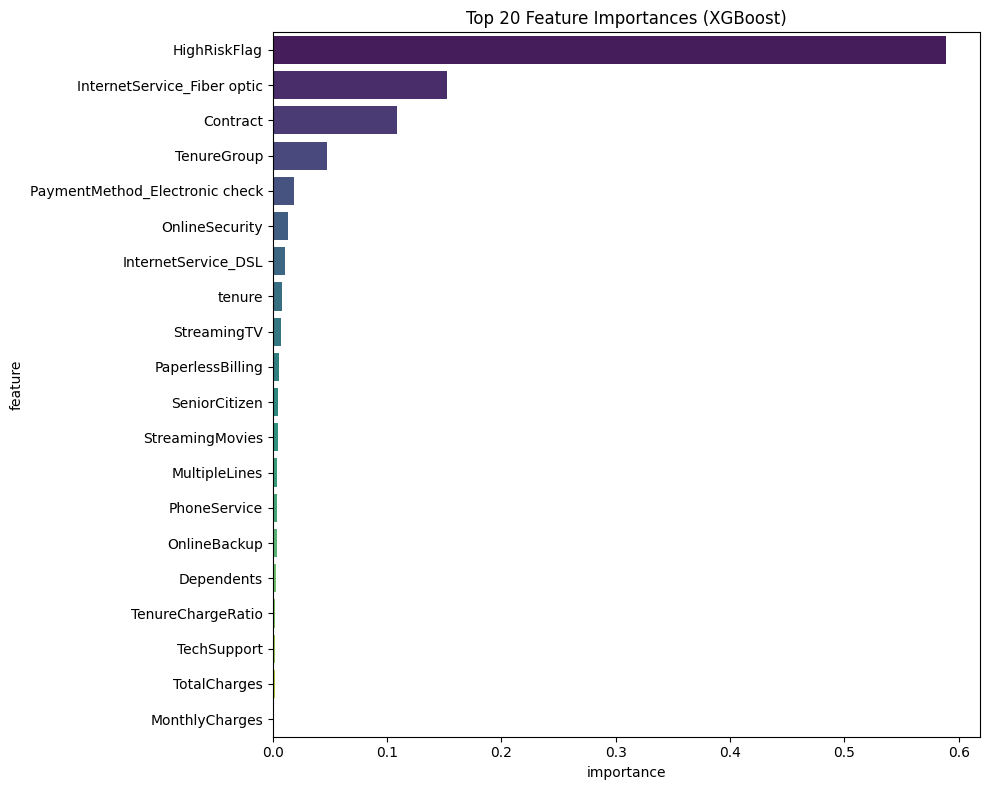

In [ ]:
importance_df = pd.DataFrame({
    'feature':    feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df.head(20), x='importance', y='feature', palette='viridis')
plt.title('Top 20 Feature Importances (XGBoost)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

In [ ]:
submission = pd.DataFrame({
    'id':    test_df['id'].values,
    'Churn': tst_preds
})
submission.to_csv('submission.csv', index=False)
print(f"\nsubmission.csv saved — {len(submission)} rows")
print(submission.head())


submission.csv saved — 254655 rows
       id     Churn
0  594194  0.074639
1  594195  0.000308
2  594196  0.104282
3  594197  0.003374
4  594198  0.509088
